In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

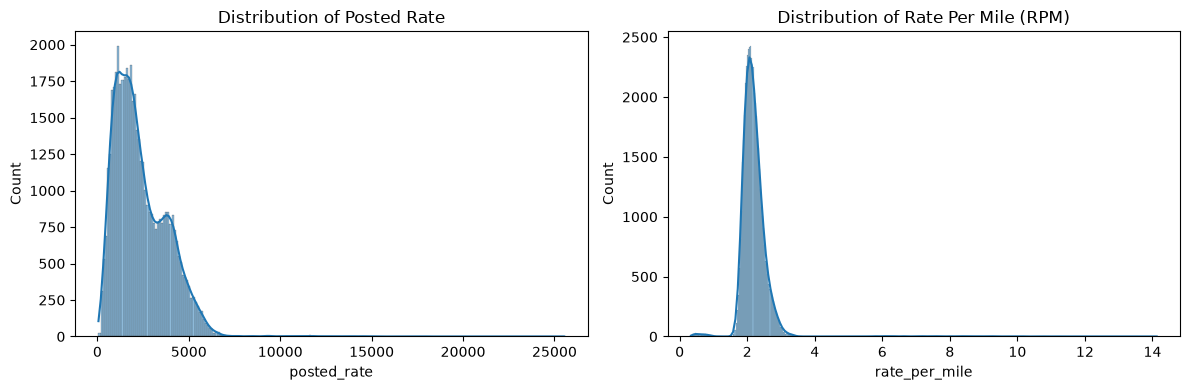

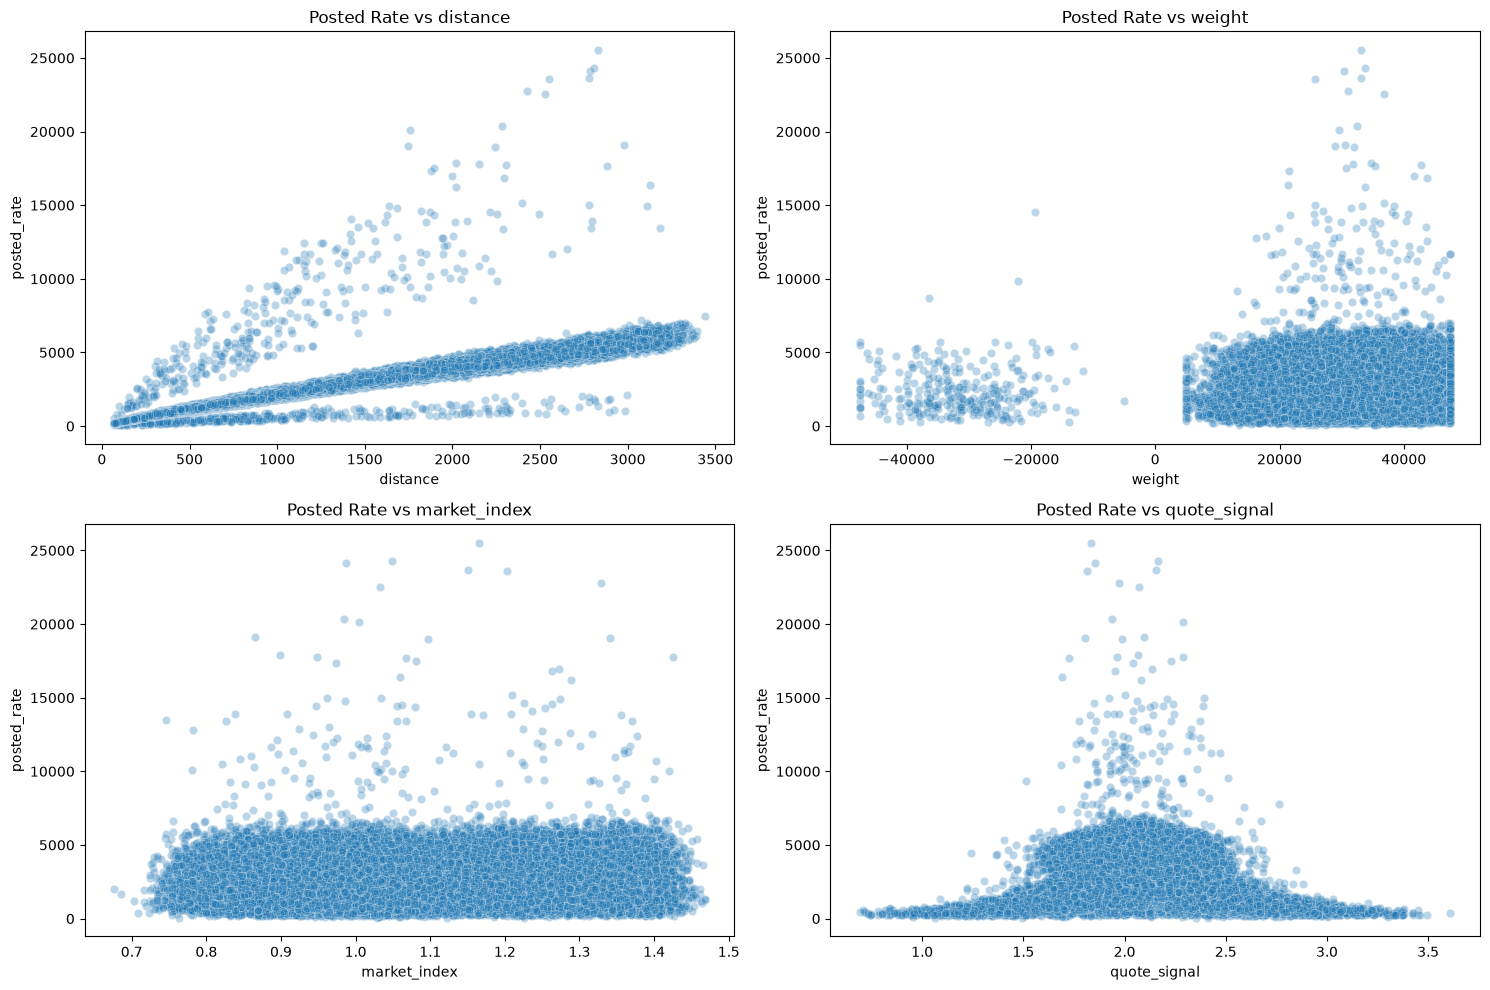

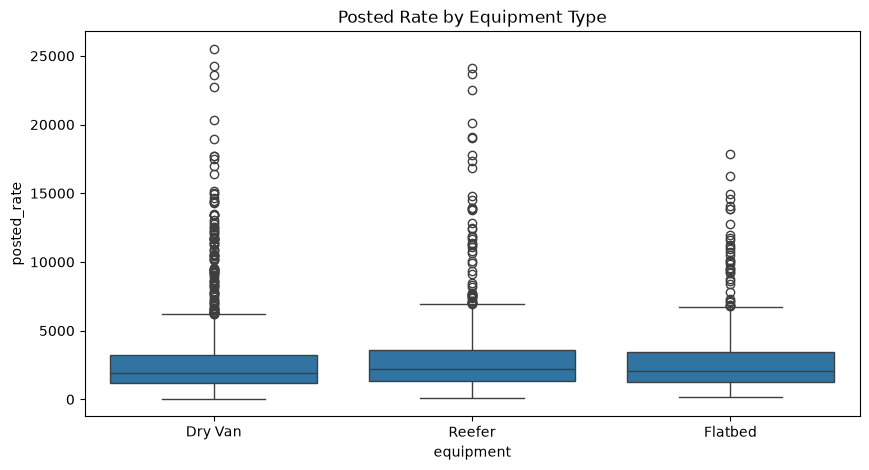

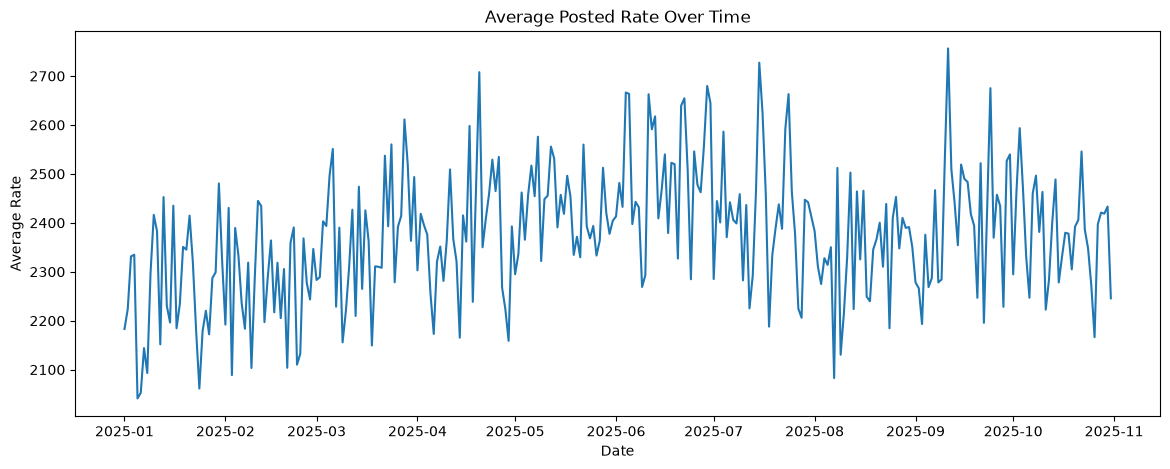

In [5]:
def run_initial_eda(csv_path):
    # Load data
    df = pd.read_csv(csv_path)
    
    # Convert date to datetime
    df['date'] = pd.to_datetime(df['date'])
    
    # 1. Target Distribution
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(df['posted_rate'], kde=True, ax=axes[0])
    axes[0].set_title('Distribution of Posted Rate')
    
    # Often, rate-per-mile (RPM) is a more stable target in freight. Let's look at it.
    df['rate_per_mile'] = df['posted_rate'] / df['distance'].replace(0, np.nan)
    sns.histplot(df['rate_per_mile'], kde=True, ax=axes[1])
    axes[1].set_title('Distribution of Rate Per Mile (RPM)')
    plt.tight_layout()
    plt.show()

    # 2. Continuous Features vs Target
    continuous_features = ['distance', 'weight', 'market_index', 'quote_signal']
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    for i, feature in enumerate(continuous_features):
        row, col = divmod(i, 2)
        sns.scatterplot(data=df, x=feature, y='posted_rate', alpha=0.3, ax=axes[row, col])
        axes[row, col].set_title(f'Posted Rate vs {feature}')
    plt.tight_layout()
    plt.show()

    # 3. Categorical Features vs Target
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=df, x='equipment', y='posted_rate')
    plt.title('Posted Rate by Equipment Type')
    plt.show()

    # 4. Temporal Trends (Time Series)
    # Group by date to see daily average rates
    daily_rates = df.groupby('date')['posted_rate'].mean().reset_index()
    plt.figure(figsize=(14, 5))
    sns.lineplot(data=daily_rates, x='date', y='posted_rate')
    plt.title('Average Posted Rate Over Time')
    plt.xlabel('Date')
    plt.ylabel('Average Rate')
    plt.show()

if __name__ == "__main__":
    # Replace with your actual path
    run_initial_eda('data/train-test.csv')

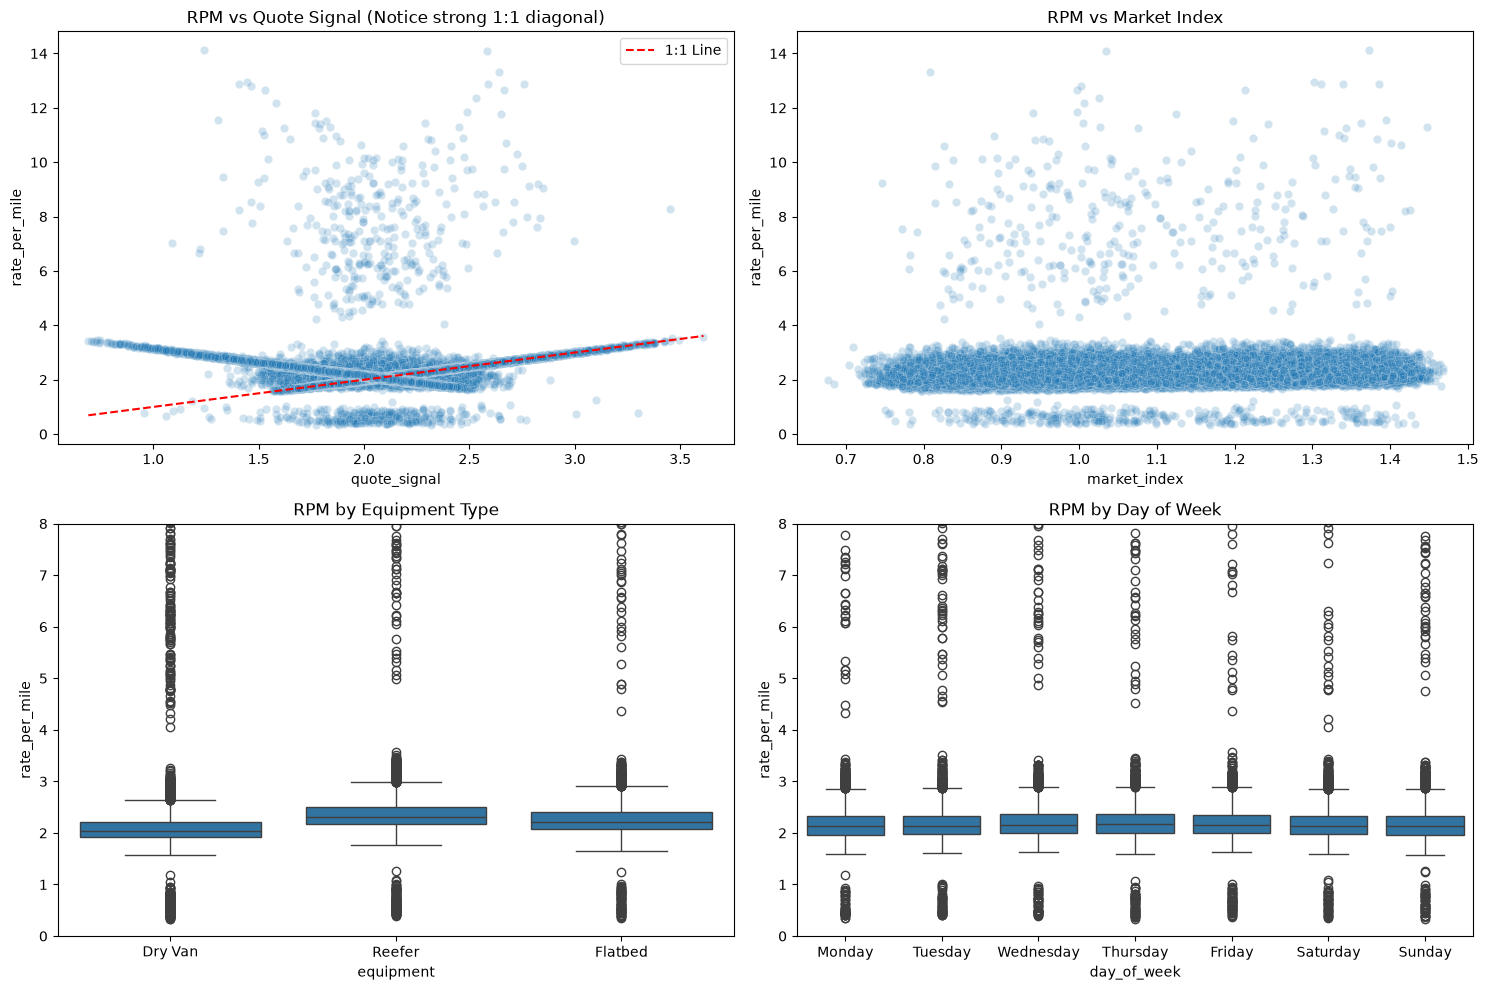

--- DATA QUALITY CHECKS ---
Total Rows: 48000
Negative Weights Count: 292
Extreme Rate Outliers (Rate > $10k): 103
Distance vs Haversine Correlation: 0.9995


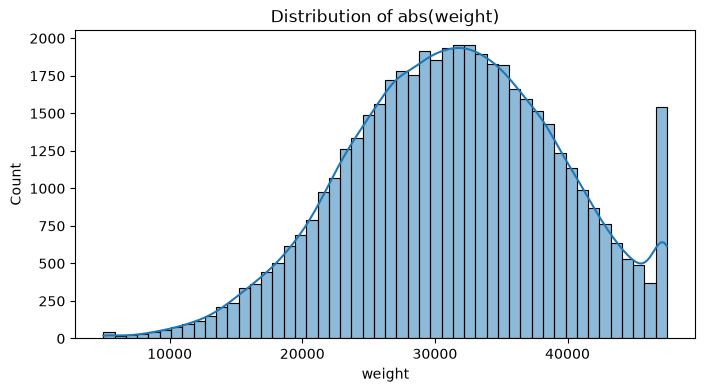

In [7]:
def haversine_np(lat1, lon1, lat2, lon2):
    """Calculates haversine distance in miles."""
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    miles = 3958.8 * c
    return miles

def run_deep_eda(csv_path):
    df = pd.read_csv(csv_path)
    df['date'] = pd.to_datetime(df['date'])
    df['rate_per_mile'] = df['posted_rate'] / df['distance']
    df['day_of_week'] = df['date'].dt.day_name()
    df['haversine_dist'] = haversine_np(df['pickup_lat'], df['pickup_lon'], 
                                        df['delivery_lat'], df['delivery_lon'])
    
    # 1. Rate Per Mile vs Key Signals
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    sns.scatterplot(data=df, x='quote_signal', y='rate_per_mile', alpha=0.2, ax=axes[0, 0])
    axes[0, 0].set_title('RPM vs Quote Signal (Notice strong 1:1 diagonal)')
    axes[0, 0].plot([df['quote_signal'].min(), df['quote_signal'].max()], 
                    [df['quote_signal'].min(), df['quote_signal'].max()], 'r--', label='1:1 Line')
    axes[0, 0].legend()

    sns.scatterplot(data=df, x='market_index', y='rate_per_mile', alpha=0.2, ax=axes[0, 1])
    axes[0, 1].set_title('RPM vs Market Index')

    sns.boxplot(data=df, x='equipment', y='rate_per_mile', ax=axes[1, 0])
    axes[1, 0].set_title('RPM by Equipment Type')
    axes[1, 0].set_ylim(0, 8)  # zoom in to see distribution without extreme outliers

    order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    sns.boxplot(data=df, x='day_of_week', y='rate_per_mile', order=order, ax=axes[1, 1])
    axes[1, 1].set_title('RPM by Day of Week')
    axes[1, 1].set_ylim(0, 8)

    plt.tight_layout()
    plt.show()

    # 2. Data Quality Checks
    print("--- DATA QUALITY CHECKS ---")
    print(f"Total Rows: {len(df)}")
    print(f"Negative Weights Count: {(df['weight'] < 0).sum()}")
    print(f"Extreme Rate Outliers (Rate > $10k): {(df['posted_rate'] > 10000).sum()}")
    print(f"Distance vs Haversine Correlation: {df['distance'].corr(df['haversine_dist']):.4f}")
    
    # Check if negative weights are just sign errors
    plt.figure(figsize=(8, 4))
    sns.histplot(np.abs(df['weight']), kde=True, bins=50)
    plt.title('Distribution of abs(weight)')
    plt.show()

if __name__ == "__main__":
    run_deep_eda('data/train-test.csv')

DATA QUALITY AUDIT: MISSING VALUES
Train/Dev Missing Values:
 weight          300
market_index    374
dtype: int64

Validation Missing Values:
 weight          165
market_index    249
dtype: int64


TEST 1: ZERO-PARAMETER FORMULA BENCHMARKS
[Dist * Baseline_RPM]
   R² Score: 0.7844 | MAE: $298.67 | RMSE: $690.37

[Dist * Quote_Signal]
   R² Score: 0.7935 | MAE: $232.34 | RMSE: $675.63

[Dist * Quote_Signal * Market_Index]
   R² Score: 0.6561 | MAE: $454.41 | RMSE: $872.01

TEST 2: RATIO METRICS (Actual Rate / Formula)
Ratio Summary: [Posted_Rate / (Dist * Quote * Market)]
count    47626.000000
mean         1.033318
std          0.358289
min          0.117034
1%           0.598697
5%           0.709674
25%          0.850748
50%          0.991163
75%          1.128665
95%          1.472451
99%          2.355150
max          8.732945
Name: ratio_dqm, dtype: float64


TEST 3: MULTIPLICATIVE POWER LAW ELASTICITY
Estimated Log Elasticities:
  Intercept (beta_0)   : 1.6169
  log(Distance) (be

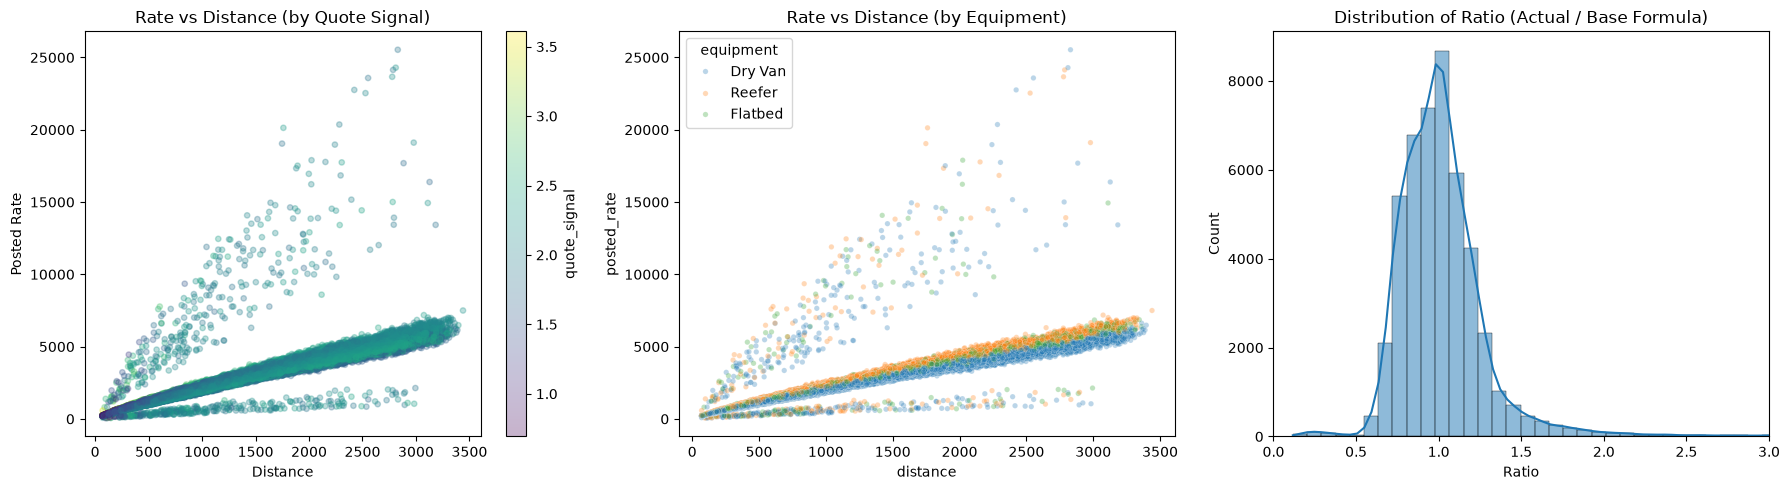

In [6]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def verify_formula_and_bands_robust(train_path, val_path=None):
    df = pd.read_csv(train_path)
    
    # -------------------------------------------------------------
    # 1. DATA QUALITY: MISSING VALUE AUDIT
    # -------------------------------------------------------------
    print("=" * 60)
    print("DATA QUALITY AUDIT: MISSING VALUES")
    print("=" * 60)
    print("Train/Dev Missing Values:\n", df.isna().sum()[df.isna().sum() > 0])
    
    if val_path:
        val_df = pd.read_csv(val_path)
        print("\nValidation Missing Values:\n", val_df.isna().sum()[val_df.isna().sum() > 0])
    print("\n")

    # -------------------------------------------------------------
    # 2. TEST 1: ZERO-PARAMETER FORMULA BENCHMARKS (NaN Safe)
    # -------------------------------------------------------------
    print("=" * 60)
    print("TEST 1: ZERO-PARAMETER FORMULA BENCHMARKS")
    print("=" * 60)
    
    # Evaluate strictly on rows where market_index is NOT null for fair comparison
    clean_mask = df['market_index'].notna() & df['posted_rate'].notna() & df['distance'].notna() & df['quote_signal'].notna()
    df_clean = df[clean_mask].copy()

    pred_base = df_clean['distance'] * (df_clean['posted_rate'] / df_clean['distance']).mean()
    pred_dq = df_clean['distance'] * df_clean['quote_signal']
    pred_dqm = df_clean['distance'] * df_clean['quote_signal'] * df_clean['market_index']

    for name, pred in [("Dist * Baseline_RPM", pred_base),
                       ("Dist * Quote_Signal", pred_dq),
                       ("Dist * Quote_Signal * Market_Index", pred_dqm)]:
        r2 = r2_score(df_clean['posted_rate'], pred)
        mae = mean_absolute_error(df_clean['posted_rate'], pred)
        rmse = np.sqrt(mean_squared_error(df_clean['posted_rate'], pred))
        print(f"[{name}]")
        print(f"   R² Score: {r2:.4f} | MAE: ${mae:.2f} | RMSE: ${rmse:.2f}\n")

    # -------------------------------------------------------------
    # 3. TEST 2: RATIO METRICS & OUTLIER DETECTION
    # -------------------------------------------------------------
    print("=" * 60)
    print("TEST 2: RATIO METRICS (Actual Rate / Formula)")
    print("=" * 60)
    df_clean['ratio_dqm'] = df_clean['posted_rate'] / pred_dqm
    print("Ratio Summary: [Posted_Rate / (Dist * Quote * Market)]")
    print(df_clean['ratio_dqm'].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))
    print("\n")

    # -------------------------------------------------------------
    # 4. TEST 3: MULTIPLICATIVE POWER LAW (OLS)
    # -------------------------------------------------------------
    print("=" * 60)
    print("TEST 3: MULTIPLICATIVE POWER LAW ELASTICITY")
    print("=" * 60)
    
    pos_mask = (df_clean['posted_rate'] > 0) & (df_clean['distance'] > 0) & \
               (df_clean['quote_signal'] > 0) & (df_clean['market_index'] > 0)
    valid = df_clean[pos_mask]

    X = np.column_stack([
        np.ones(len(valid)),
        np.log(valid['distance']),
        np.log(valid['quote_signal']),
        np.log(valid['market_index'])
    ])
    y = np.log(valid['posted_rate'])
    
    betas = np.linalg.inv(X.T @ X) @ X.T @ y
    print("Estimated Log Elasticities:")
    print(f"  Intercept (beta_0)   : {betas[0]:.4f}")
    print(f"  log(Distance) (beta_1): {betas[1]:.4f} (Ideal: 1.00)")
    print(f"  log(Quote)    (beta_2): {betas[2]:.4f} (Ideal: 1.00)")
    print(f"  log(Market)   (beta_3): {betas[3]:.4f} (Ideal: 1.00)\n")

    # -------------------------------------------------------------
    # 5. TEST 4: VISUAL INSPECTION
    # -------------------------------------------------------------
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Scatter colored by quote_signal
    sc1 = axes[0].scatter(df['distance'], df['posted_rate'], c=df['quote_signal'], 
                          cmap='viridis', alpha=0.3, s=15)
    fig.colorbar(sc1, ax=axes[0], label='quote_signal')
    axes[0].set_title('Rate vs Distance (by Quote Signal)')
    axes[0].set_xlabel('Distance')
    axes[0].set_ylabel('Posted Rate')

    # Scatter colored by equipment
    sns.scatterplot(data=df, x='distance', y='posted_rate', hue='equipment', 
                    alpha=0.3, ax=axes[1], s=15)
    axes[1].set_title('Rate vs Distance (by Equipment)')

    # Ratio histogram
    sns.histplot(df_clean['ratio_dqm'], bins=100, kde=True, ax=axes[2])
    axes[2].set_xlim(0, 3)
    axes[2].set_title('Distribution of Ratio (Actual / Base Formula)')
    axes[2].set_xlabel('Ratio')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    verify_formula_and_bands_robust('data/train-test.csv', 'data/validation.csv')

In [7]:
import pandas as pd
import numpy as np

df = pd.read_csv('data/train-test.csv')
df['weight'] = df['weight'].abs()
df['rate_per_mile'] = df['posted_rate'] / df['distance']
df['expected_base'] = df['distance'] * df['quote_signal']
df['multiplier'] = df['posted_rate'] / df['expected_base']

# 1. Segment into the 3 visual bands
bottom_band = df[df['rate_per_mile'] < 1.0].copy()
main_band   = df[(df['rate_per_mile'] >= 1.0) & (df['rate_per_mile'] <= 3.8)].copy()
top_cloud   = df[df['rate_per_mile'] > 3.8].copy()

print("=" * 60)
print(f"BAND SIZES:")
print(f"  Bottom Band (RPM < 1.0) : {len(bottom_band):>5} rows ({len(bottom_band)/len(df)*100:.2f}%)")
print(f"  Main Band   (Normal)    : {len(main_band):>5} rows ({len(main_band)/len(df)*100:.2f}%)")
print(f"  Top Cloud   (RPM > 3.8) : {len(top_cloud):>5} rows ({len(top_cloud)/len(df)*100:.2f}%)")
print("=" * 60)

# 2. Inspect Multiplier (Actual / Expected)
print("\n--- MULTIPLIER SUMMARY (Actual Rate / [Dist * Quote]) ---")
print(f"Bottom Band Multiplier Median: {bottom_band['multiplier'].median():.3f}")
print(f"Main Band Multiplier Median  : {main_band['multiplier'].median():.3f}")
print(f"Top Cloud Multiplier Median  : {top_cloud['multiplier'].median():.3f}")

# 3. Print sample rows from Top Cloud and Bottom Band
print("\n--- SAMPLE ROWS: TOP CLOUD (High Rates) ---")
print(top_cloud[['load_id', 'pickup', 'delivery', 'equipment', 'distance', 'weight', 'quote_signal', 'posted_rate', 'multiplier']].head(5))

print("\n--- SAMPLE ROWS: BOTTOM BAND (Low Rates) ---")
print(bottom_band[['load_id', 'pickup', 'delivery', 'equipment', 'distance', 'weight', 'quote_signal', 'posted_rate', 'multiplier']].head(5))

BAND SIZES:
  Bottom Band (RPM < 1.0) :   329 rows (0.69%)
  Main Band   (Normal)    : 47331 rows (98.61%)
  Top Cloud   (RPM > 3.8) :   340 rows (0.71%)

--- MULTIPLIER SUMMARY (Actual Rate / [Dist * Quote]) ---
Bottom Band Multiplier Median: 0.297
Main Band Multiplier Median  : 1.004
Top Cloud Multiplier Median  : 3.615

--- SAMPLE ROWS: TOP CLOUD (High Rates) ---
        load_id          pickup      delivery equipment  distance   weight  \
388   TR-000389  Corpus Christi   Chattanooga   Flatbed     823.0  39556.0   
469   TR-000470         Phoenix  Jacksonville   Dry Van    2154.3  22509.0   
785   TR-000786     Kansas City    Charleston   Dry Van     861.5  28959.0   
870   TR-000871           Tulsa   Baton Rouge    Reefer     305.6  26447.0   
1149  TR-001150         Houston   Baton Rouge   Flatbed     170.3  28954.0   

      quote_signal  posted_rate  multiplier  
388        2.22467      5485.49    2.996056  
469        1.76215     10854.69    2.859357  
785        1.91323      

# Data Preparation

In [11]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

def engineer_features(df):
    """
    Cleans, imputes, and engineers features strictly aligned with the technical report.
    (No row dropping happens here, just transformations).
    """
    df = df.copy()
    
    # 1. Clean Dates & Target Anomaly (Negative Weights)
    df['date'] = pd.to_datetime(df['date'])
    if 'weight' in df.columns:
        df['weight'] = df['weight'].abs()
        # Impute missing weights using equipment medians
        equip_medians = df.groupby('equipment')['weight'].transform('median')
        df['weight'] = df['weight'].fillna(equip_medians).fillna(32000.0)
    
    # 2. Impute Market Index (Temporal Fill)
    if 'market_index' in df.columns:
        df = df.sort_values('date').reset_index(drop=True)
        # Forward fill, then backward fill, fallback to 1.0
        df['market_index'] = df['market_index'].ffill().bfill().fillna(1.0)
        
    # 3. Core Domain Features (Based on Report)
    df['base_rate_dq'] = df['distance'] * df['quote_signal']
    df['base_rate_dqm'] = df['distance'] * df['quote_signal'] * df['market_index']
    df['ton_miles'] = (df['weight'] / 2000.0) * df['distance']
    
    # 4. Temporal Features
    df['month'] = df['date'].dt.month
    df['quarter'] = df['date'].dt.quarter
    df['day_of_year'] = df['date'].dt.dayofyear
    
    # 5. Spatial Feature
    df['lane'] = df['pickup'].astype(str) + "_to_" + df['delivery'].astype(str)
        
    return df

def run_data_preparation():
    print("Loading datasets...")
    train_df = pd.read_csv('data/train-test.csv')
    val_df = pd.read_csv('data/validation.csv')
    dec_df = pd.read_csv('data/december-chart-inputs.csv')

    # Add split identifiers so we can safely combine them
    train_df['split'] = 'train'
    val_df['split'] = 'val'
    dec_df['split'] = 'dec'
    
    # Combine everything to ensure consistent categorical encodings and feature math
    print("Engineering features across all datasets...")
    all_data = pd.concat([train_df, val_df, dec_df], ignore_index=True)
    
    # Apply feature engineering
    all_data = engineer_features(all_data)
    
    # Consistently cast categoricals across the entire dataset space
    cat_cols = ['equipment', 'pickup', 'delivery', 'lane']
    for col in cat_cols:
        all_data[col] = all_data[col].astype('category')
        
    # Split them back apart
    print("Splitting datasets back out...")
    train_clean = all_data[all_data['split'] == 'train'].copy()
    val_clean = all_data[all_data['split'] == 'val'].copy()
    dec_clean = all_data[all_data['split'] == 'dec'].copy()
    
    # --- Filter Injected Label Noise (TRAINING DATA ONLY) ---
    print("Filtering synthetic label noise from training data...")
    train_clean['multiplier'] = train_clean['posted_rate'] / train_clean['base_rate_dq']
    valid_mask = (train_clean['multiplier'] >= 0.5) & (train_clean['multiplier'] <= 2.5)
    dropped = (~valid_mask).sum()
    print(f"Dropped {dropped} rows of synthetic label noise from the training split.")
    
    # Apply mask and clean up helper columns
    train_clean = train_clean[valid_mask].drop(columns=['multiplier', 'split'])
    val_clean = val_clean.drop(columns=['split'])
    dec_clean = dec_clean.drop(columns=['split'])
    
    print("\n--- FINAL DATA SHAPES ---")
    print(f"Train Data : {train_clean.shape}")
    print(f"Val Data   : {val_clean.shape}")
    print(f"Dec Data   : {dec_clean.shape}")
    
    # Save the prepared files out so the training script can pick them up
    print("\nSaving prepared files to 'data/prepared_*.csv'...")
    train_clean.to_csv('data/prepared_train.csv', index=False)
    val_clean.to_csv('data/prepared_validation.csv', index=False)
    dec_clean.to_csv('data/prepared_december.csv', index=False)
    
    print("Data preparation complete!")

if __name__ == "__main__":
    run_data_preparation()

Loading datasets...


Engineering features across all datasets...
Splitting datasets back out...
Filtering synthetic label noise from training data...
Dropped 833 rows of synthetic label noise from the training split.

--- FINAL DATA SHAPES ---
Train Data : (47167, 22)
Val Data   : (12000, 22)
Dec Data   : (31, 22)

Saving prepared files to 'data/prepared_*.csv'...
Data preparation complete!
